In [50]:
from Models import aggregate_model, IndividualModel

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.interpolate import make_interp_spline

from matplotlib.lines import Line2D

from pathlib import Path
import math

In [51]:
df_fit = pd.read_csv("best_fit_ebm.csv")
df_u25 = pd.read_csv("u25.csv") #ABM 100 simulations

u25_mat = df_u25.pivot(index="id", columns="t", values="population")
u25_mat = u25_mat.sort_index(axis=1)

sims_u25 = u25_mat.to_numpy(dtype=float)

In [52]:
c = df_fit.loc[0, "c"]
m = df_fit.loc[0, "m"]
n = df_fit.loc[0, "n"]
d = df_fit.loc[0, "d"]
k = df_fit.loc[0, "k"]
R = df_fit.loc[0, "R"]
nrmse = df_fit.loc[0, "RMSE_EBM"]

T = 2000
P_0 = 10
s_0 = 0
z = 4

t_ED = np.array([0, 80, 315, 560, 736, 800, 900, 1000, 1280, 1350, 1480], dtype=int)
p_ED = np.array([8, 20, 620, 2200, 2056, 1800, 1500, 1250, 680, 320, 95], dtype=float)

In [53]:
S_ts, P_ts = aggregate_model(T, c, m, n, d, k, R, P_0, s_0)
S_ts_EBM = S_ts
P_ts_EBM = P_ts

model_abm = IndividualModel(T, c, m, n, d, k, R, P_0, s_0, z)
model_abm.setup()
model_abm.run()

S_ts_ABM = model_abm.S_ts
P_ts_ABM = model_abm.P_ts

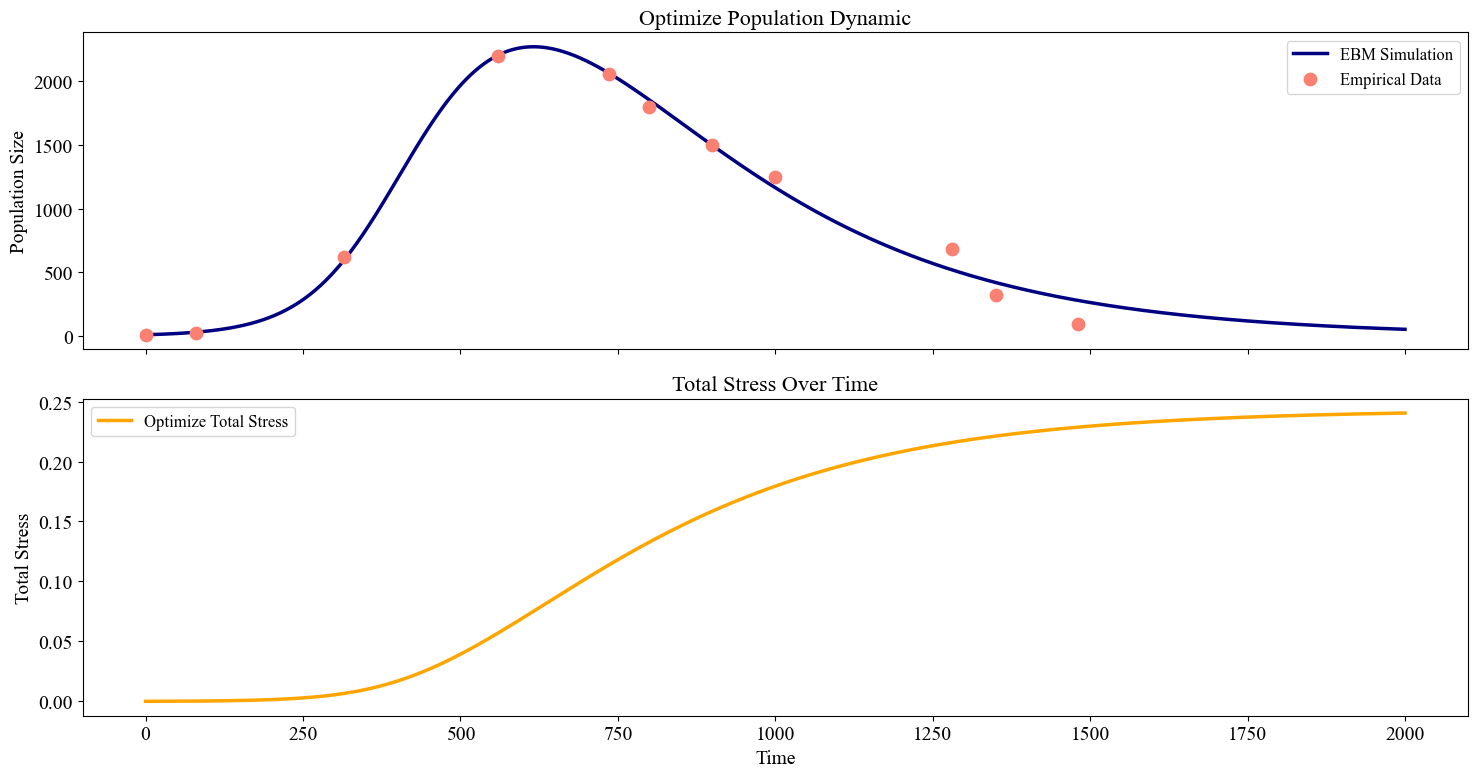

In [54]:
FIGSIZE = (15, 8)
LINEWIDTH = 2.5
MARKER_SIZE = 80
FONT_SIZE = 14

COLOR_EBM = "navy"
COLOR_ED = "salmon"
COLOR_STRESS = "orange"

TITLE_SIZE = 16
LABEL_SIZE = 14
LEGEND_SIZE = 12

plt.rcParams.update({
    "font.size": FONT_SIZE,
    "axes.titlesize": TITLE_SIZE,
    "axes.labelsize": LABEL_SIZE,
    "legend.fontsize": LEGEND_SIZE
})

fig, axes = plt.subplots(2, 1, figsize=FIGSIZE, sharex=True)

ax = axes[0]
ax.plot(P_ts_EBM, label="EBM Simulation", color=COLOR_EBM, linewidth=LINEWIDTH)
ax.scatter(t_ED, p_ED, label="Empirical Data", color=COLOR_ED, s=MARKER_SIZE, zorder=3)
ax.set_ylabel("Population Size")
ax.set_title("Optimize Population Dynamic")
ax.legend()

ax = axes[1]
ax.plot(S_ts_EBM, label="Optimize Total Stress", color=COLOR_STRESS, linewidth=LINEWIDTH)
ax.set_ylabel("Total Stress")
ax.set_xlabel("Time")
ax.set_title("Total Stress Over Time")
ax.legend()

plt.tight_layout()
plt.show()

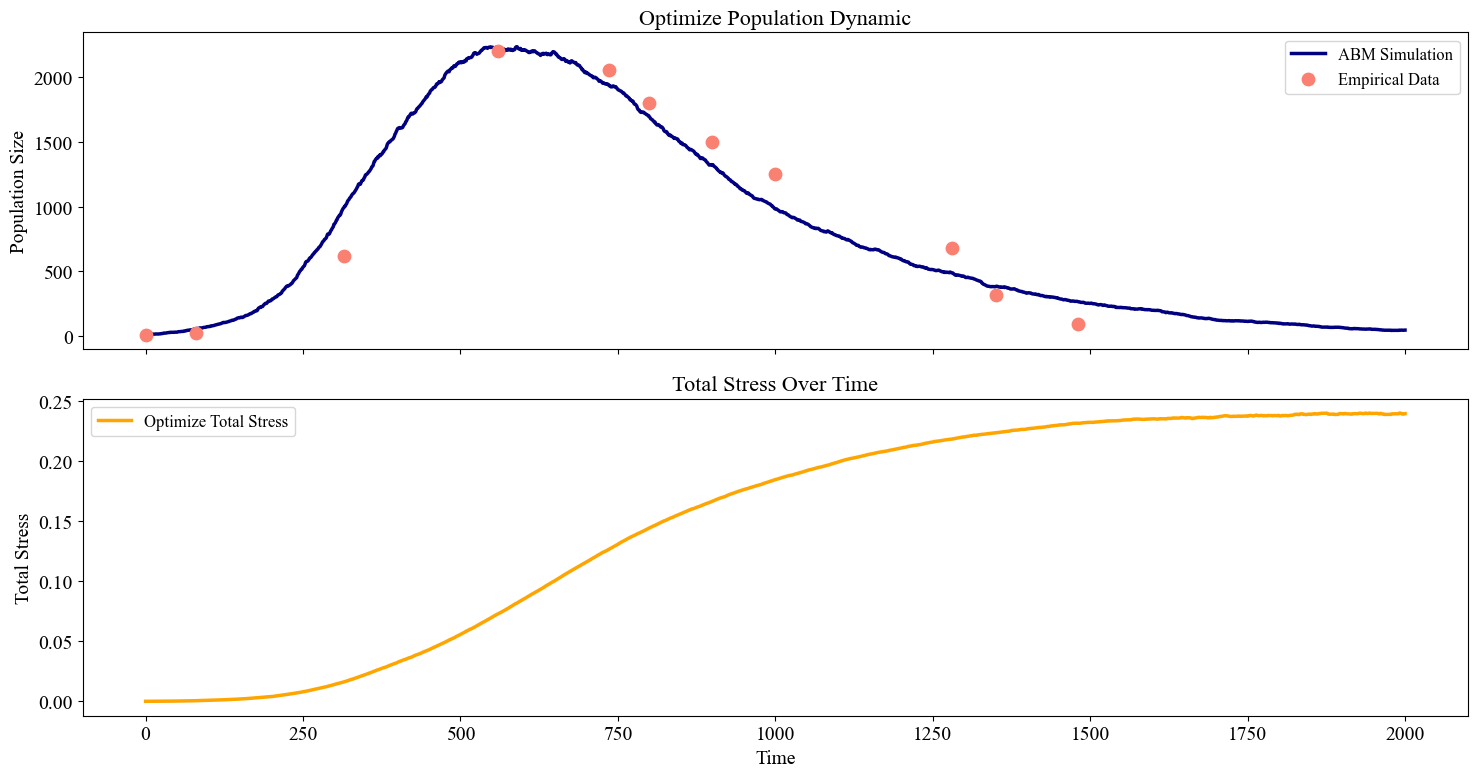

In [55]:
FIGSIZE = (15, 8)
LINEWIDTH = 2.5
MARKER_SIZE = 80
FONT_SIZE = 14

COLOR_EBM = "navy"
COLOR_ED = "salmon"
COLOR_STRESS = "orange"

TITLE_SIZE = 16
LABEL_SIZE = 14
LEGEND_SIZE = 12

plt.rcParams.update({
    "font.size": FONT_SIZE,
    "axes.titlesize": TITLE_SIZE,
    "axes.labelsize": LABEL_SIZE,
    "legend.fontsize": LEGEND_SIZE
})

fig, axes = plt.subplots(2, 1, figsize=FIGSIZE, sharex=True)

ax = axes[0]
ax.plot(P_ts_ABM, label="ABM Simulation", color=COLOR_EBM, linewidth=LINEWIDTH)
ax.scatter(t_ED, p_ED, label="Empirical Data", color=COLOR_ED, s=MARKER_SIZE, zorder=3)
ax.set_ylabel("Population Size")
ax.set_title("Optimize Population Dynamic")
ax.legend()

ax = axes[1]
ax.plot(S_ts_ABM, label="Optimize Total Stress", color=COLOR_STRESS, linewidth=LINEWIDTH)
ax.set_ylabel("Total Stress")
ax.set_xlabel("Time")
ax.set_title("Total Stress Over Time")
ax.legend()

plt.tight_layout()
plt.show()

In [56]:
NUM_SIM = sims_u25.shape[0]

t_u25 = np.arange(sims_u25.shape[1], dtype=float)
idx_u25 = np.arange(NUM_SIM)

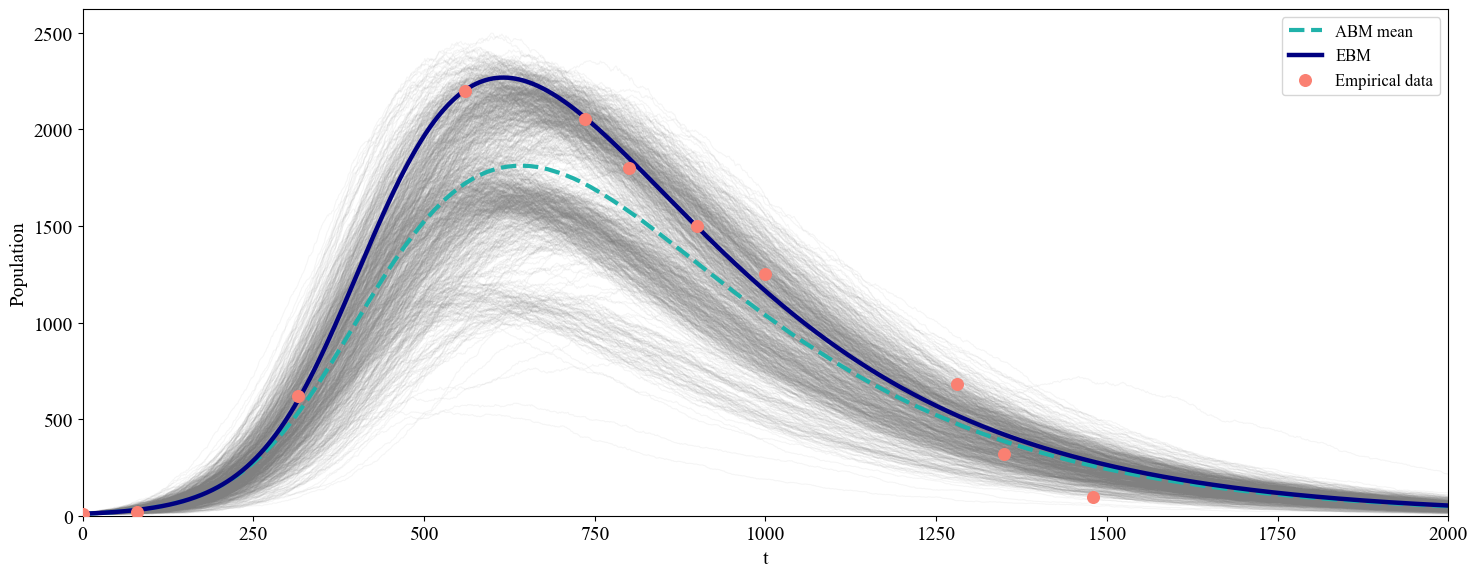

In [57]:
mean_u25 = np.nanmean(sims_u25, axis=0)
t_u25 = np.arange(sims_u25.shape[1], dtype=float)

fig, ax = plt.subplots(figsize=(15, 6))

# spaghetti ABM (senza legenda)
for i in range(sims_u25.shape[0]):
    ax.plot(t_u25, sims_u25[i], color="grey", linewidth=0.8, alpha=0.08)

# media ABM
ax.plot(t_u25, mean_u25,
        color="lightseagreen",
        linewidth=3.0,
        linestyle="--",
        label="ABM mean")

# EBM
S_ebm_u25, P_ebm_u25 = aggregate_model(T, c, m, n, d, k, R, P_0, s_0)
P_ebm_u25 = np.asarray(P_ebm_u25, dtype=float)
t_ebm_u25 = np.arange(len(P_ebm_u25), dtype=float)

ax.plot(t_ebm_u25, P_ebm_u25,
        color="navy",
        linewidth=3.2,
        label="EBM")

ax.scatter(t_ED, p_ED,
           color="salmon",
           s=70,
           zorder=5,
           label="Empirical data")

ax.legend()

ax.set_xlabel("t")
ax.set_ylabel("Population")
ax.set_ylim(bottom=0)
ax.set_xlim(0, max(t_u25.max(), t_ebm_u25.max()))

plt.tight_layout()
plt.show()

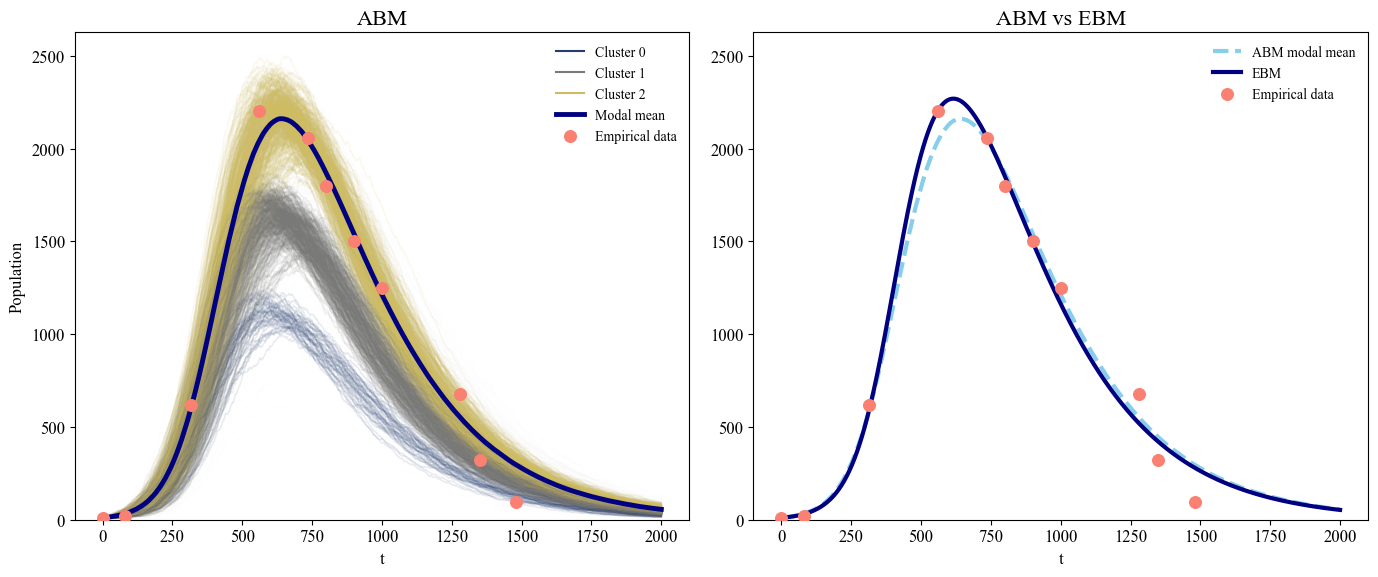

In [ ]:
# =========================================================
# STYLE
# =========================================================
NOISE_COLOR = "lightgrey"
NOISE_ALPHA = 0.01

CLUSTER_ALPHA = 0.1
CMAP = plt.cm.cividis
MODAL_COLOR = "navy"
MODAL_LW = 3.5

ABM_COLOR = "skyblue"
ABM_LS = "--"

EBM_COLOR = "navy"
EMP_COLOR = "salmon"

TITLE_SIZE = 16
LABEL_SIZE = 12
TICK_SIZE = 12
LEGEND_SIZE = 10

TITLE_WEIGHT = "normal"
LABEL_WEIGHT = "normal"
TICK_WEIGHT = "normal"

FONT_FAMILY = "Times New Roman"

# =========================================================
# OPERATIONS
# =========================================================
all_data = pd.read_csv("all_data.csv")
clusters = pd.read_csv("clusters.csv")
nrmse = pd.read_csv("NRMSE_param_variation.csv")
cluster_map = pd.read_csv("cluster_peak_mapping.csv")

best = nrmse.loc[nrmse["variation"].eq(0)].sort_values("NRMSE").iloc[0]
p, v = best["parameter"], best["variation"]

pivot = (
    all_data.loc[all_data["param"].eq(p) & all_data["variation"].eq(v)]
    .pivot(index="t", columns="id", values="population")
    .sort_index()
)

t = pivot.index.to_numpy(float)
ids = pivot.columns.astype(str)
Y = pivot.to_numpy(float)

labs = clusters.loc[
    clusters["param"].eq(p) & clusters["variation"].eq(v),
    ["id", "cluster"]
].copy()
labs["id"] = labs["id"].astype(str)

remap = cluster_map.loc[
    cluster_map["param"].eq(p) & cluster_map["variation"].eq(v),
    ["old_cluster", "new_cluster"]
].drop_duplicates()

labs = labs.merge(remap, left_on="cluster", right_on="old_cluster", how="left")
labs["cluster_mapped"] = labs["new_cluster"]
labs.loc[labs["cluster"].eq(-1), "cluster_mapped"] = -1

id_to_cluster = labs.set_index("id")["cluster_mapped"].to_dict()
cluster_per_id = np.array([id_to_cluster.get(i, -1) for i in ids], float)

valid = labs.loc[labs["cluster"].ne(-1), "cluster"]
modal_old = valid.value_counts().idxmax() if len(valid) else None
modal_ids = set(labs.loc[labs["cluster"].eq(modal_old), "id"]) if modal_old is not None else set(ids)
modal_mask = np.array([i in modal_ids for i in ids])
mean = Y[:, modal_mask].mean(axis=1)

clust_ids = sorted(set(cluster_per_id) - {-1})
vals = np.linspace(0.15, 0.82, len(clust_ids))
colors = {c: CMAP(v) for c, v in zip(clust_ids, vals)}

_, P_ebm = aggregate_model(T, c, m, n, d, k, R, P_0, s_0)
P_ebm = np.asarray(P_ebm, float)
t_ebm = np.arange(len(P_ebm), dtype=float)

y_lim = 1.05 * max(np.nanmax(Y), np.nanmax(P_ebm), np.max(p_ED))

# =========================================================
# PLOT
# =========================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for j in range(Y.shape[1]):
    y = Y[:, j]
    cl = cluster_per_id[j]

    if np.isnan(cl) or cl == -1:
        ax1.plot(t, y, color=NOISE_COLOR, alpha=NOISE_ALPHA, lw=0.8)
    else:
        ax1.plot(t, y, color=colors[cl], alpha=CLUSTER_ALPHA, lw=1)

for c_id in clust_ids:
    ax1.plot([], [], color=colors[c_id], lw=1.5, label=f"Cluster {int(c_id)}")

ax1.plot(t, mean, color=MODAL_COLOR, lw=MODAL_LW, label="Modal mean")
ax1.scatter(t_ED, p_ED, color=EMP_COLOR, s=70, zorder=5, label="Empirical data")

ax1.set_title("ABM", fontsize=TITLE_SIZE, fontweight=TITLE_WEIGHT, fontfamily=FONT_FAMILY)
ax1.set_xlabel("t", fontsize=LABEL_SIZE, fontweight=LABEL_WEIGHT, fontfamily=FONT_FAMILY)
ax1.set_ylabel("Population", fontsize=LABEL_SIZE, fontweight=LABEL_WEIGHT, fontfamily=FONT_FAMILY)
ax1.set_ylim(0, y_lim)
ax1.tick_params(axis="both", labelsize=TICK_SIZE)
ax1.legend(frameon=False, prop={"family": FONT_FAMILY, "size": LEGEND_SIZE})

ax2.plot(t, mean, color=ABM_COLOR, ls=ABM_LS, lw=3, label="ABM modal mean")
ax2.plot(t_ebm, P_ebm, color=EBM_COLOR, lw=3, label="EBM")
ax2.scatter(t_ED, p_ED, color=EMP_COLOR, s=70, zorder=5, label="Empirical data")

ax2.set_title("ABM vs EBM", fontsize=TITLE_SIZE, fontweight=TITLE_WEIGHT, fontfamily=FONT_FAMILY)
ax2.set_xlabel("t", fontsize=LABEL_SIZE, fontweight=LABEL_WEIGHT, fontfamily=FONT_FAMILY)
ax2.set_ylim(0, y_lim)
ax2.tick_params(axis="both", labelsize=TICK_SIZE)
ax2.legend(frameon=False, prop={"family": FONT_FAMILY, "size": LEGEND_SIZE})

for ax in (ax1, ax2):
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontfamily(FONT_FAMILY)
        lbl.set_fontweight(TICK_WEIGHT)

plt.tight_layout()
plt.show()

C:\Users\FedericoCarucci\AppData\Local\Temp\ipykernel_24712\2584040422.py:84: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(COLORMAP_NAME)


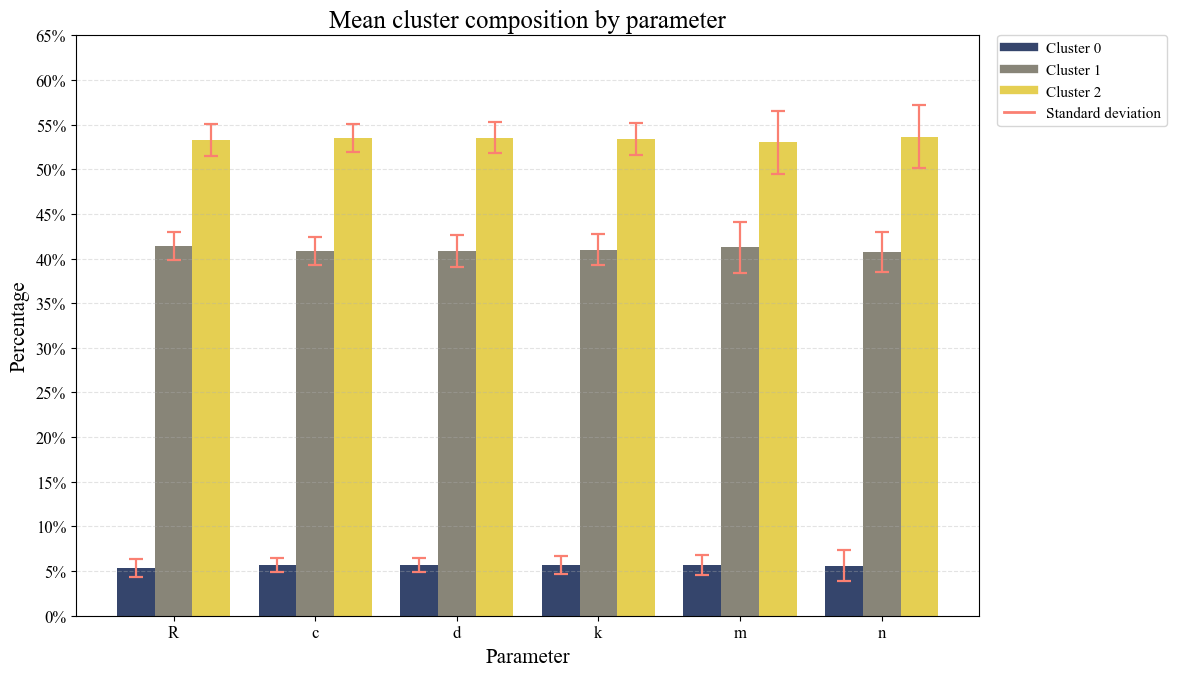

In [65]:
# =========================================================
# SETTINGS
# =========================================================
FIGSIZE = (12, 7)

FONT_FAMILY = "Times New Roman"
TITLE_SIZE = 18
AXIS_LABEL_SIZE = 15
TICK_SIZE = 12
LEGEND_SIZE = 11

BAR_WIDTH_TOTAL = 0.8

COLORMAP_NAME = "cividis"

ERROR_COLOR = "salmon"
ERROR_LINEWIDTH = 1.6
ERROR_CAPSIZE = 5
ERROR_CAPTHICK = 1.6

Y_MARGIN_TOP = 4
Y_TICK_STEP = 5

TITLE = "Mean cluster composition by parameter"
Y_LABEL = "Percentage"
X_LABEL = "Parameter"

# =========================================================
# LOAD
# =========================================================
clusters = pd.read_csv("clusters.csv")
mapping = pd.read_csv("cluster_peak_mapping.csv")

# =========================================================
# FONT
# =========================================================
plt.rcParams["font.family"] = FONT_FAMILY

# =========================================================
# MERGE: riallineamento cluster
# =========================================================
clusters = clusters.merge(
    mapping,
    how="left",
    left_on=["param", "variation", "cluster"],
    right_on=["param", "variation", "old_cluster"]
)

clusters["cluster"] = np.where(
    clusters["cluster"] == -1,
    -1,
    clusters["new_cluster"]
)

clusters = clusters[clusters["cluster"] != -1].copy()

# =========================================================
# COUNTS
# =========================================================
counts = (
    clusters.groupby(["param", "variation", "cluster"])
    .size()
    .reset_index(name="count")
)

totals = counts.groupby(["param", "variation"])["count"].transform("sum")
counts["perc"] = 100 * counts["count"] / totals

summary = (
    counts.groupby(["param", "cluster"])["perc"]
    .agg(["mean", "std"])
    .reset_index()
)

# =========================================================
# ORDER
# =========================================================
param_order = sorted(summary["param"].unique())
cluster_order = sorted(summary["cluster"].unique())

# =========================================================
# COLORS
# =========================================================
cmap = plt.cm.get_cmap(COLORMAP_NAME)
colors = cmap(np.linspace(0.2, 0.9, len(cluster_order)))
cluster_colors = {cl: colors[i] for i, cl in enumerate(cluster_order)}

# =========================================================
# POSITIONS
# =========================================================
x = np.arange(len(param_order))
n_clusters = len(cluster_order)
bar_width = BAR_WIDTH_TOTAL / n_clusters

fig, ax = plt.subplots(figsize=FIGSIZE)

# =========================================================
# PLOT
# =========================================================
for i, cl in enumerate(cluster_order):
    sub = summary[summary["cluster"] == cl].copy()
    sub = sub.set_index("param").reindex(param_order).reset_index()

    xpos = x - BAR_WIDTH_TOTAL / 2 + bar_width / 2 + i * bar_width

    means = sub["mean"].to_numpy()
    stds = sub["std"].fillna(0).to_numpy()

    ax.bar(
        xpos,
        means,
        width=bar_width,
        color=cluster_colors[cl],
        yerr=stds,
        error_kw={
            "ecolor": ERROR_COLOR,
            "elinewidth": ERROR_LINEWIDTH,
            "capsize": ERROR_CAPSIZE,
            "capthick": ERROR_CAPTHICK
        },
        label=f"Cluster {int(cl)}"
    )

# =========================================================
# Y RANGE
# =========================================================
y_max = np.ceil((summary["mean"] + summary["std"].fillna(0)).max() + Y_MARGIN_TOP)
ax.set_ylim(0, y_max)

ytop_rounded = int(np.ceil(y_max / Y_TICK_STEP) * Y_TICK_STEP)
yticks = np.arange(0, ytop_rounded + 1, Y_TICK_STEP)

ax.set_yticks(yticks)
ax.set_yticklabels([f"{int(t)}%" for t in yticks])

# =========================================================
# STYLE
# =========================================================
ax.set_xticks(x)
ax.set_xticklabels(param_order, fontsize=TICK_SIZE)
ax.tick_params(axis="y", labelsize=TICK_SIZE)

ax.set_ylabel(Y_LABEL, fontsize=AXIS_LABEL_SIZE)
ax.set_xlabel(X_LABEL, fontsize=AXIS_LABEL_SIZE)
ax.set_title(TITLE, fontsize=TITLE_SIZE)

ax.grid(axis="y", linestyle="--", alpha=0.35)

# =========================================================
# LEGEND (outside, no title)
# =========================================================
cluster_handles = [
    Line2D([0], [0], color=cluster_colors[cl], lw=6, label=f"Cluster {int(cl)}")
    for cl in cluster_order
]

std_handle = Line2D(
    [0], [0],
    color=ERROR_COLOR,
    lw=2,
    label="Standard deviation"
)

ax.legend(
    handles=cluster_handles + [std_handle],
    fontsize=LEGEND_SIZE,
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0
)

plt.tight_layout()
plt.show()

In [62]:
# ===== EBM =====
ebm_df = pd.read_csv("best_fit_ebm.csv")
nrmse_ebm = ebm_df["RMSE_EBM"].iloc[0]

# ===== ABM =====
abm_df = pd.read_csv("NRMSE_param_variation.csv")
abm_best = abm_df[abm_df["variation"] == 0].sort_values("NRMSE").iloc[0]

nrmse_abm = abm_best["NRMSE"]
best_param = abm_best["parameter"]

print(f"EBM NRMSE: {nrmse_ebm:.4f}")
print(f"ABM NRMSE: {nrmse_abm:.4f}")

EBM NRMSE: 0.0391
ABM NRMSE: 0.0450


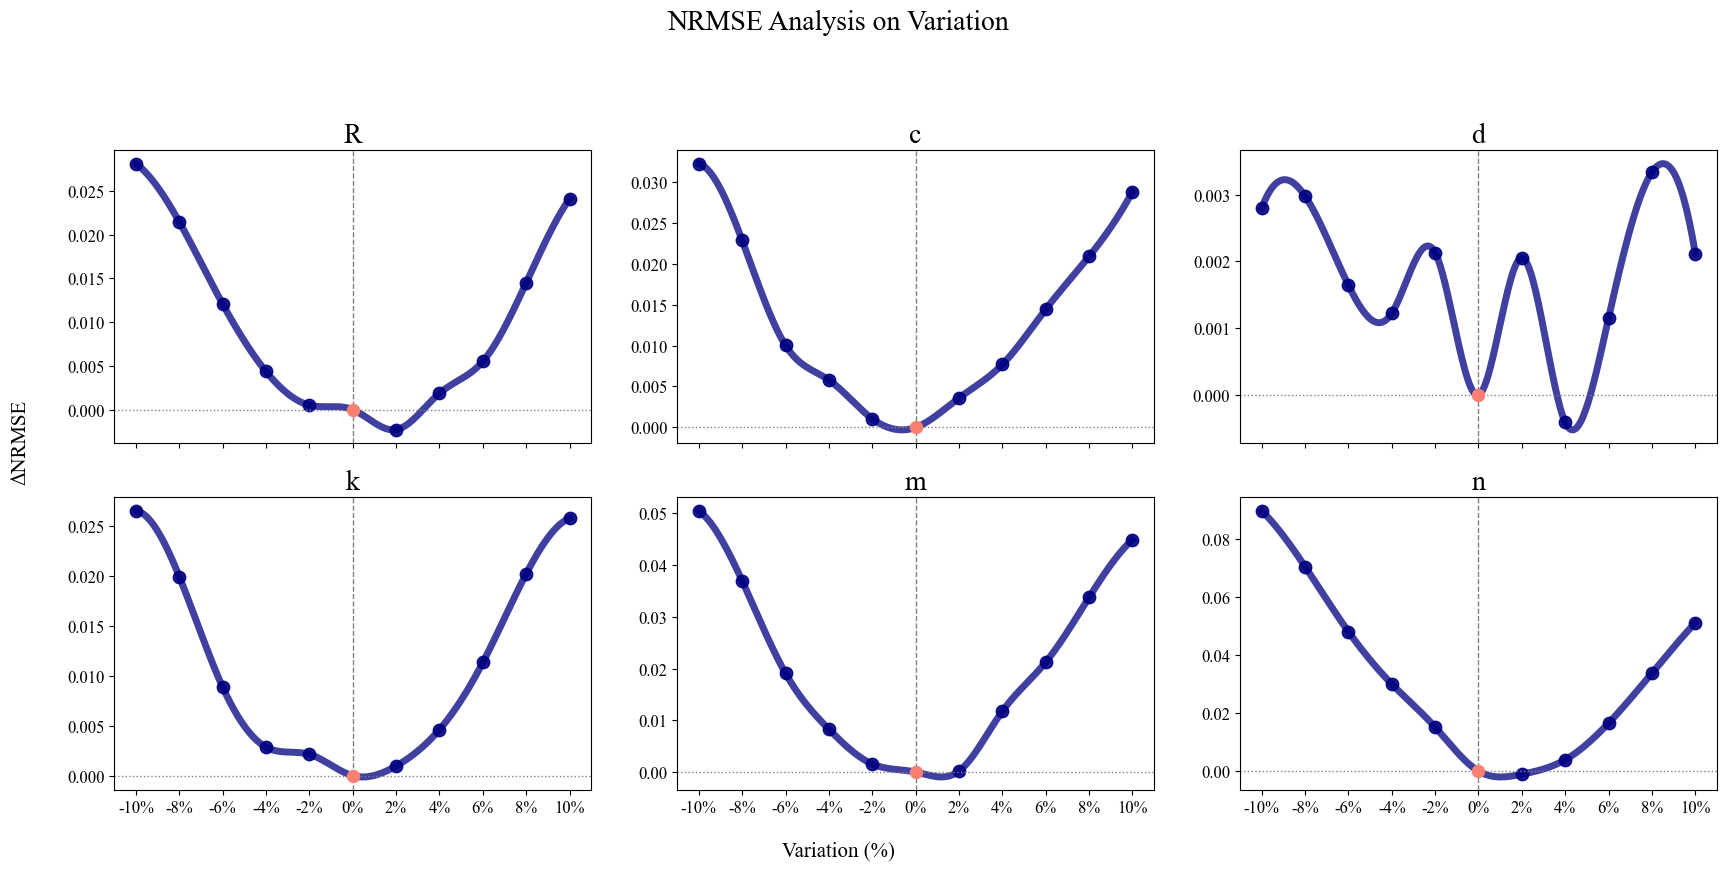

In [80]:
smooth = True

def parse_variation(v):
    v = str(v).strip()

    if v == "p00":
        return 0
    if v.startswith("p") and v[1:].isdigit():
        return int(v[1:])
    if v.startswith("m") and v[1:].isdigit():
        return -int(v[1:])

    try:
        return float(v)
    except ValueError:
        return np.nan


# =========================================================
# FONT CONTROL
# =========================================================

FONT_FAMILY = "Times New Roman"

SUPTITLE_SIZE = 20
TITLE_SIZE = 20
AXIS_LABEL_SIZE = 15
TICK_SIZE = 12

SUPTITLE_WEIGHT = "normal"
TITLE_WEIGHT = "normal"
AXIS_LABEL_WEIGHT = "normal"
TICK_WEIGHT = "normal"


# =========================================================
# STYLE
# =========================================================
POINT_COLOR = "navy"
BASELINE_POINT_COLOR = "salmon"
LINE_COLOR = "navy"

POINT_SIZE = 80
BASELINE_POINT_SIZE = 75
LINE_WIDTH = 5.0

POINT_ALPHA = 0.9
BASELINE_POINT_ALPHA = 1.0
LINE_ALPHA = 0.75

TITLE = "NRMSE Analysis on Variation"


# =========================================================
# DATA
# =========================================================
df = pd.read_csv("NRMSE_param_variation.csv")
df["parameter"] = df["parameter"].astype(str).str.strip()
df["variation_num"] = df["variation"].map(parse_variation)
df["NRMSE"] = pd.to_numeric(df["NRMSE"], errors="coerce")

params = ["R", "c", "d", "k", "m", "n"]
params = [p for p in params if p in df["parameter"].unique()]

ncols = 3
nrows = math.ceil(len(params) / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(6 * ncols, 4.5 * nrows),
    sharex=True
)

axes = np.array(axes).reshape(nrows, ncols)


# =========================================================
# PLOT
# =========================================================
for i, param in enumerate(params):
    r, c = divmod(i, ncols)
    ax = axes[r, c]

    sub = df[df["parameter"] == param].copy()
    sub = sub.dropna(subset=["variation_num", "NRMSE"])
    sub = sub.sort_values("variation_num")

    x = sub["variation_num"].to_numpy(dtype=float)
    y = sub["NRMSE"].to_numpy(dtype=float)

    baseline = sub.loc[sub["variation_num"] == 0, "NRMSE"]
    y0 = baseline.iloc[0] if len(baseline) > 0 else 0.0
    y = y - y0

    if len(x) >= 3 and smooth:
        xs = np.linspace(x.min(), x.max(), 300)
        ys = make_interp_spline(x, y, k=min(3, len(x) - 1))(xs)
        ax.plot(xs, ys, color=LINE_COLOR, linewidth=LINE_WIDTH, alpha=LINE_ALPHA)
    else:
        ax.plot(x, y, color=LINE_COLOR, linewidth=LINE_WIDTH, alpha=LINE_ALPHA)

    mask0 = x == 0
    mask_not0 = x != 0

    ax.scatter(
        x[mask_not0], y[mask_not0],
        s=POINT_SIZE, color=POINT_COLOR, alpha=POINT_ALPHA
    )

    ax.scatter(
        x[mask0], y[mask0],
        s=BASELINE_POINT_SIZE, color=BASELINE_POINT_COLOR,
        alpha=BASELINE_POINT_ALPHA, zorder=5
    )

    ax.axvline(0, linestyle="--", linewidth=1, color="gray")
    ax.axhline(0, linestyle=":", linewidth=1, color="gray")

    ax.set_title(
        param,
        fontsize=TITLE_SIZE,
        fontfamily=FONT_FAMILY,
        fontweight=TITLE_WEIGHT
    )

    ax.set_xticks(x)

    # mostra le etichette x solo nell'ultima riga
    if r == nrows - 1:
        ax.set_xticklabels([f"{int(v)}%" for v in x])
    else:
        ax.tick_params(axis="x", labelbottom=False)

    ax.tick_params(axis="both", labelsize=TICK_SIZE)

    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontfamily(FONT_FAMILY)
        lbl.set_fontweight(TICK_WEIGHT)


# spegne gli assi vuoti
for j in range(len(params), nrows * ncols):
    r, c = divmod(j, ncols)
    axes[r, c].axis("off")


# =========================================================
# GLOBAL LABELS
# =========================================================
fig.suptitle(
    TITLE,
    fontsize=SUPTITLE_SIZE,
    fontfamily=FONT_FAMILY,
    fontweight=SUPTITLE_WEIGHT
)

fig.text(
    0.5, 0.04, "Variation (%)",
    ha="center",
    fontsize=AXIS_LABEL_SIZE,
    fontfamily=FONT_FAMILY,
    fontweight=AXIS_LABEL_WEIGHT
)

fig.text(
    0.04, 0.5, "ΔNRMSE",
    va="center",
    rotation="vertical",
    fontsize=AXIS_LABEL_SIZE,
    fontfamily=FONT_FAMILY,
    fontweight=AXIS_LABEL_WEIGHT
)

plt.tight_layout(rect=[0.06, 0.06, 1, 0.93])
plt.show()